Model Engineering
===

___

Author: <u>*Virtsudo*</u>

Date: **May 2026**

## 0. Utils preparation

### 0.1 Imports and Plots

In [17]:
# imports
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch_geometric.loader import DataLoader as GDataLoader
from torch_geometric.data import Dataset as GDataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from torch_geometric.data import Data
from matplotlib import pyplot as plt
import torch_geometric.nn as gnn
import torch.nn.functional as f
from functools import partial
import torch.optim as optim
import seaborn as sns
from torch import nn
import pandas as pd
import numpy as np
import unicodedata
import torch
import time
import re

In [18]:
# file naming wrapper
def name_wrapper(text: str, fallback: str = "file", max_len: int = 255) -> str:
    cleaned = "".join(ch for ch in re.sub(r"\s+", "_", unicodedata.normalize("NFKC", text.lower()).strip()) if ch.isalnum() or ch in {"_", "-", "."}).rstrip(" .")
    if not cleaned: cleaned = fallback
    return cleaned[:max_len]

In [77]:
# plots
def plot_train_val_curve(title: str, train_losses: list, val_losses: list):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss of {title}")
    plt.legend()
    plt.savefig(f"../report/img/train_val_curve_{name_wrapper(title)}.png")
    plt.show()

def plot_confusion_matrix(title: str, y_true: list, y_pred: list, class_names: list[str]):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix of {title}")
    plt.savefig(f"../report/img/confusion_matrix_{name_wrapper(title)}.png")
    plt.show()

def plot_histogram(title: str, items1: list[int], items2: list[int], x: str = None, y: str = None):
    plt.figure(figsize=(10, 5))
    bins = np.arange(min(min(items1), min(items2)), max(max(items1), max(items2)) + 2)
    sns.histplot(items1, bins=bins, stat="density", alpha=0.45, label="Train", color="tab:blue")
    sns.histplot(items2,  bins=bins, stat="density", alpha=0.45, label="Test",  color="tab:orange")
    if x is not None: plt.xlabel(x)
    if y is not None: plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../report/img/hist_{name_wrapper(title)}.png")
    plt.show()

def plot_bar(title: str, mm: dict):
    names = list(mm.keys())
    macro_f1   = [m["macro avg"]["f1-score"] for m in mm.values()]
    normal_rec = [m["normal"]["recall"]      for m in mm.values()]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, macro_f1,   width, label="Macro F1")
    bars2 = ax.bar(x + width/2, normal_rec, width, label="Normal Recall")

    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"../report/img/bar_{name_wrapper(title)}.png")
    plt.show()

### 0.2 Reusable components

In [20]:
# general config
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {str(device).upper()}")

Device: CUDA


In [21]:
# define custom dataset class for handling data
class APICallDataset(Dataset):
    def __init__(self, ids: list[list[int]], labels: list[int]):
        self.ids = ids
        self.labels = labels

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx: int):
        sequence = torch.tensor(self.ids[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).unsqueeze(-1)
        return sequence, label

In [22]:
# define custom dataset class for graph
class GraphDataset(GDataset):
    def __init__(self, adj_matrices, features, labels, transform=None):
        super().__init__(transform=transform)
        self.graphs = []

        for i in range(len(adj_matrices)):
            row, col = np.where(adj_matrices[i] == 1)    # edge index (2 x num_edges)
            edge_index = torch.from_numpy(np.vstack((row, col))).long()

            x = torch.tensor(features[i], dtype=torch.float)    # node features

            if x.dim() == 2 and x.size(1) > 1:      # convert One-Hot to indices if needed
                x = torch.argmax(x, dim=1).long()

            y = torch.tensor(labels[i], dtype=torch.long) # graph label

            self.graphs.append(Data(x=x, edge_index=edge_index, y=y))

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]

In [23]:
# define FFNN model
class FFNN(nn.Module):
    def __init__(self, input_dim: int = -1, vocab_size: int = -1, embed_dim: int = -1, hidden_dim: int = -1, output_dim: int = 1, padding_idx = -1, dropout: float = 0.0, is_embed: bool = False):
        super().__init__()

        layers = list()
        self.is_embed = is_embed

        if self.is_embed:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
            layers.append(nn.Linear(embed_dim, hidden_dim))
        else: layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.is_embed:
            x = self.embedding(x)
            x, _ = torch.max(x, dim=1)
        x = x.float()
        return self.net(x)

In [24]:
# define RNN model
class RNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, output_dim: int, num_layers: int, padding_idx: int, dropout: float = 0.0, is_lstm: bool = False, bidirectional: bool = False):
        """
        Initialize the RNN model.
        :param vocab_size: length of features' vocabulary
        :param embed_dim: embedding dimension
        :param hidden_dim: size of hidden layers
        :param output_dim: output size, on our case 1
        :param num_layers: number of layers on RNN
        :param padding_idx: position of pad token on features' vocabulary
        :param dropout: regularization parameter
        :param is_lstm: use lstm or not
        :param bidirectional: use bidirectional or not
        """
        super().__init__()

        self.bidirectional = bidirectional
        self.is_lstm = is_lstm

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        if is_lstm:
            self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=bidirectional)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=bidirectional)
        self.linear = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the RNN model.
        :param x: Input tensor
        :param lengths: Lengths of sequences
        :return: Output logits
        """
        embedded = self.dropout(self.embedding(x))
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True)
        if self.is_lstm:
            out, (h, cell) = self.lstm(packed_embedded)
        else:
            out, h = self.rnn(packed_embedded)

        if self.bidirectional:
            out, _ = pad_packed_sequence(out, batch_first=True)
            hidden_cat = torch.cat((h[-2], h[-1]), dim=1)
            return self.linear(hidden_cat)
        else:
            return self.linear(h[-1])

In [25]:
# define GNN model
class GNN(nn.Module):
    def __init__(self, num_node_types: int, embed_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.0, is_sage: bool = False):
        super().__init__()

        self.embedding = nn.Embedding(num_node_types, embed_dim)
        if is_sage:
            self.conv1 = gnn.SAGEConv(embed_dim, hidden_dim)
            self.conv2 = gnn.SAGEConv(hidden_dim, hidden_dim)
        else:
            self.conv1 = gnn.GCNConv(embed_dim, hidden_dim)
            self.conv2 = gnn.GCNConv(hidden_dim, hidden_dim)

        self.dropout = torch.nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, data):
        x = self.embedding(data.x)
        edge_idx, batch = data.edge_index, data.batch

        x = f.relu(self.conv1(x, edge_idx))
        x = self.dropout(x)

        x = f.relu(self.conv2(x, edge_idx))
        x = self.dropout(x)

        x = gnn.global_mean_pool(x, batch)
        x = self.fc(x)

        return x

In [26]:
# define GraphAT
class GAT(torch.nn.Module):
    def __init__(self, num_node_types: int, embed_dim: int, hidden_dim: int, output_dim: int, heads: int = 2, dropout: float = 0.0):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_node_types, embed_dim)
        self.dropout_layer = torch.nn.Dropout(dropout)
        self.conv1 = gnn.GATConv(embed_dim, hidden_dim, heads=heads, concat=True, dropout=dropout)
        self.conv2 = gnn.GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False, dropout=dropout)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x = self.embedding(data.x)
        edge_index, batch = data.edge_index, data.batch

        x = self.dropout_layer(x)
        x = f.elu(self.conv1(x, edge_index))
        x = self.dropout_layer(x)

        x = f.elu(self.conv2(x, edge_index))
        x = gnn.global_mean_pool(x, batch)

        x = self.fc(x)
        return x

In [27]:
# define steppers
def ffnn_stepper(batch, device):
    X, y = batch
    return X.to(device), y.to(device)

def rnn_stepper(batch, device):
    X, lengths, y = batch
    return (X.to(device), lengths.to(device)), y.to(device)

def gnn_stepper(batch, device):
    batch = batch.to(device)
    return batch, batch.y.float().unsqueeze(-1)

In [28]:
# define training loop
def training_loop(model, train_loader, val_loader, device, optimizer, criterion, num_epochs, plot_title, stepper, min_delta = None, patience = None):
    """
    Train the model for a specified number of epochs and track the training and validation losses.

    Args:
        :param model: The neural network model to be trained (FFNN, RNN, GNN)
        :param train_loader: DataLoader for the training dataset
        :param val_loader: DataLoader for the validation dataset.
        :param device: Device to run the model on (CPU or GPU).
        :param optimizer: The optimization algorithm to use for updating model parameters.
        :param criterion: The loss function to use for computing the loss.
        :param num_epochs: Number of epochs to train the model.
        :param plot_title: Title of the plot.
        :param stepper: Structure batch on generalized form.
        :param min_delta: difference value for early stopping.
        :param patience: Number of patience to wait for improvement.

    Returns:
            None: The function plots the training and validation loss over the epochs.
    """
    start_time = time.time()
    train_losses, val_losses = list(), list()
    best_val_loss, trigger_times, best_model_state = float('inf'), 0, None

    for epoch in range(num_epochs):
        train_loss, val_loss = 0, 0

        model.train()
        for batch in train_loader:
            inputs, batch_y = stepper(batch, device)
            optimizer.zero_grad()
            outputs = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_y.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                inputs, batch_y = stepper(batch, device)
                val_outputs = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
                loss = criterion(val_outputs, batch_y)
                val_loss += loss.item() * batch_y.size(0)

            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

        if min_delta is not None and patience is not None:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
                    break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    end_time = time.time()
    print(f'The function took {end_time - start_time:.4f} seconds to execute.')
    plot_train_val_curve(plot_title, train_losses, val_losses)
    return

In [29]:
# define testing model
def testing_model(model, dataloader, device, plot_title, stepper):
    """
    Evaluate the model on a given dataloader and compute accuracy.
    Args:
        :param model: The trained model (FFNN, RNN, GNN).
        :param dataloader: DataLoader for the dataset.
        :param device: Device to run the model on (CPU or GPU).
        :param plot_title: Title of the plot.
        :param stepper: Structure batch on generalized form.

    Returns:
        dict: Metrics report of the model on the test dataset.
    """
    start_time = time.time()
    all_labels, all_preds = list(), list()
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = stepper(batch, device)
            logits = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
            logits, labels = logits.squeeze(-1), labels.squeeze(-1).long()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.3).long()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    end_time = time.time()
    print(f'The function took {end_time - start_time:.4f} seconds to execute.')

    print(f"\n\nClass Report {plot_title}:\n{classification_report(all_labels, all_preds, zero_division=0.0, target_names=["normal", "malware"])}")
    plot_confusion_matrix(plot_title, all_labels, all_preds, ["normal", "malware"])
    return classification_report(all_labels, all_preds, zero_division=0.0, target_names=["normal", "malware"], output_dict=True)

In [30]:
# define api to id mapping function
def seq_api_to_id(seqs: list[list], api2idx: dict, max_len: int = None) -> list:
    ids = list()
    for s in seqs:
        idx = [api2idx.get(api, api2idx['<UNK>']) for api in s]
        if max_len is not None:
            if len(idx) > max_len:
                idx = idx[:max_len]
            elif len(idx) < max_len:
                idx += [api2idx['<PAD>']] * (max_len - len(idx))
        ids.append(idx)
    return ids

In [31]:
# collate function to add padding per each batch
def collate_fn(batch, pad_index):
    """
    Custom collate function for DataLoader to handle variable-length sequences.
    Sorts sequences by length (descending) for efficient RNN processing and pads them.

    Args:
        batch: List of (sequence, label) tuples

    Returns:
        tuple: (padded_sequences, sequence_lengths, sorted_labels)
    """
    ids, labels = zip(*batch) # Unpack batch
    lengths = torch.tensor([len(i) for i in ids]) # Sequence lengths

    # Sort sequences by length (descending) to optimize RNN processing
    sorted_indices = lengths.argsort(descending=True)
    ids = [ids[i] for i in sorted_indices]
    labels = torch.stack([labels[i] for i in sorted_indices]) # Convert to tensor
    lengths = lengths[sorted_indices] # Sort lengths too

    # Pad sequences to have uniform length in a batch
    padded_ids = pad_sequence(ids, batch_first=True, padding_value=pad_index)

    return padded_ids, lengths, labels

In [32]:
# define build graph dataset function
def build_graph_data(df, api_to_idx, add_self_loops=True):
    """
    Converts a DataFrame containing sequences of API calls into graphs
    compatible with PyTorch Geometric.

    Args:
        df (pd.DataFrame): must contain 'api_call_sequence' and 'is_malware'.
        api_to_idx (dict): mapping API -> index for the global one-hot encoding.
        add_self_loops (bool): if True, self-loops are added to each graph.

    Returns:
        adj_matrices (list[np.ndarray]): adjacency matrices for each graph.
        features (list[np.ndarray]): feature matrices for each graph.
        labels (list[int]): integer labels corresponding to malware/benign.
    """
    adj_matrices = []
    features = []
    labels = []

    for _, row in df.iterrows():
        seq = row["api_call_sequence"]
        label = int(row["is_malware"])  # 0 ou 1

        node_count = len(seq)
        feat_size = len(api_to_idx)

        # Build adjacency matrix, connect each API call to the next
        adj = np.zeros((node_count, node_count), dtype=np.int8)
        for i in range(node_count - 1):
            adj[i, i + 1] = 1

        # Optional self-loops to allow nodes to keep their own state
        if add_self_loops:
            np.fill_diagonal(adj, 1)

        # One-hot encoding for each API call; unknown calls map to "<UNK>"
        feat = np.zeros((node_count, feat_size), dtype=np.float32)
        for i, api in enumerate(seq):
            idx = api_to_idx.get(api, api_to_idx.get("<UNK>", 0))
            feat[i, idx] = 1

        # Store graph data
        adj_matrices.append(adj)
        features.append(feat)
        labels.append(label)

    # Here to see the distribution
    unique, counts = np.unique(labels, return_counts=True)
    distribution = dict(zip(unique, counts))
    print(f"Distribution of labels in this DataFrame : {distribution}")

    return adj_matrices, features, labels

## 1. Frequency-based baseline

### 1.1 Preprocessing

In [33]:
# read dataset
df_train = pd.read_json("../data/train.json")
df_test = pd.read_json("../data/test.json")

In [34]:
# extract sequences(api) and labels
train_seqs = df_train['api_call_sequence'].tolist()
test_seqs = df_test['api_call_sequence'].tolist()

In [35]:
# extract labels
train_labels = df_train['is_malware'].tolist()
test_labels = df_test['is_malware'].tolist()

In [36]:
# create train and test vocabulary unique api
train_vocab_set = {api_call for train_seq in train_seqs for api_call in train_seq}
test_vocab_set = {api_call for test_seq in test_seqs for api_call in test_seq}

In [37]:
print(f"Number of unique API calls the training set contain: {len(train_vocab_set)}")
print(f"Number of unique API calls the test set contain: {len(test_vocab_set)}")

Number of unique API calls the training set contain: 258
Number of unique API calls the test set contain: 232


In [38]:
# features, which appear only in test set, and not in train set
only_in_test = test_vocab_set - train_vocab_set
print(f"Number of unique API calls only the test set contain(but not in the training set): {len(only_in_test)}")
print(f"Unique API calls only the test set contain: {only_in_test}")

Number of unique API calls only the test set contain(but not in the training set): 3
Unique API calls only the test set contain: {'ControlService', 'NtDeleteKey', 'WSASocketA'}


In [39]:
# sorted vocabulary
train_vocab = sorted([i for i in train_vocab_set])
test_vocab = sorted([i for i in test_vocab_set])

# instruction check
print(train_vocab[:5])
print(test_vocab[:5])

['CertOpenStore', 'CertOpenSystemStoreW', 'CoCreateInstance', 'CoCreateInstanceEx', 'CoGetClassObject']
['CoCreateInstance', 'CoCreateInstanceEx', 'CoGetClassObject', 'CoInitializeEx', 'CoInitializeSecurity']


We build vocabulary based on features, so features (or vocabulary) of training set and test set must match. The features, which appear only in test set we assign with special token `<UNK>`.

In [40]:
# add <UNK> to assign unknown features for train set
feature_names = train_vocab + ['<UNK>']

In [41]:
# map api with their positions as id
api_to_idx = { feature_names[i]: i for i in range(len(feature_names)) }

# creating features for train
X_train = list()
for seq in train_seqs:
    freq = [0 for _ in range(len(feature_names))]   # frequency vector for train features
    for api_call in seq:
        if api_call in api_to_idx:
            freq[api_to_idx[api_call]] += 1
    X_train.append(freq)

# creating features for train
X_test = list()
for seq in test_seqs:
    freq = [0 for _ in range(len(feature_names))]   # frequency vector for test features
    for api_call in seq:
        if api_call in api_to_idx:
            freq[api_to_idx[api_call]] += 1     # UNK features, which are only on test
        else:
            freq[-1] += 1
    X_test.append(freq)

In [42]:
# sparsity for the train set (non-zero per row)
nnz_train_per_row = list()  # num of non zeros

for freq in X_train:
    nnz_train_per_row.append(sum([1 if i > 0 else 0 for i in freq]))

avg_non_zero_train = sum(nnz_train_per_row) / len(X_train)
print(f"Average non-zero elements per row in training set: {avg_non_zero_train:.2f}")
ratio_train = avg_non_zero_train / len(feature_names)
print(f"Ratio with respect to the number of elements per row in training set: {ratio_train:.2f}\n")


# sparsity for the test set (non-zero per row)
nnz_test_per_row = list()  # num of non zeros

for freq in X_test:
    nnz_test_per_row.append(sum([1 if i > 0 else 0 for i in freq]))

avg_non_zero_test = sum(nnz_test_per_row) / len(X_test)
print(f"Average non-zero elements per row in test set: {avg_non_zero_test:.2f}")
ratio_test = avg_non_zero_test / len(feature_names)
print(f"Ratio with respect to the number of elements per row in test set: {ratio_test:.2f}")

Average non-zero elements per row in training set: 21.95
Ratio with respect to the number of elements per row in training set: 0.08

Average non-zero elements per row in test set: 24.28
Ratio with respect to the number of elements per row in test set: 0.09


Frequency-based dataframe based on appearance counts of each unique API calls. It doesn't provide API order.

### 1.2 Classification

In [43]:
# convert to numpy array
X_train_array = np.array(X_train, dtype=np.float32)
X_test_array = np.array(X_test, dtype=np.float32)

y_train_array = np.array(train_labels)
y_test_array = np.array(test_labels)

In [44]:
# classifier with hyperparameter choice
grid_parameters = {'C': [0.01, 0.1, 1.0, 10.0]}
base_classifier = LogisticRegression(max_iter=3000, class_weight="balanced", n_jobs=-1)
grid = GridSearchCV(estimator=base_classifier, param_grid=grid_parameters, scoring="f1", cv=3, n_jobs=-1, verbose=1)

grid.fit(X_train_array, y_train_array)
best_classifier = grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


Used GridSearchCV with C ∈ {0.01, 0.1, 1.0, 10.0}, 3-fold CV, scoring on F1, and class_weight='balanced' to handle the imbalanced dataset. The best C was selected automatically by GridSearchCV but its value was not explicitly logged. Final test performance: macro F1 = 0.64, normal recall = 0.81, malware F1 = 0.94 — reasonably strong for a simple frequency baseline.



Class Report Baseline (Logistic Regression/Grid Search):
              precision    recall  f1-score   support

      normal       0.22      0.81      0.35       243
     malware       0.99      0.89      0.94      6262

    accuracy                           0.89      6505
   macro avg       0.61      0.85      0.64      6505
weighted avg       0.96      0.89      0.91      6505



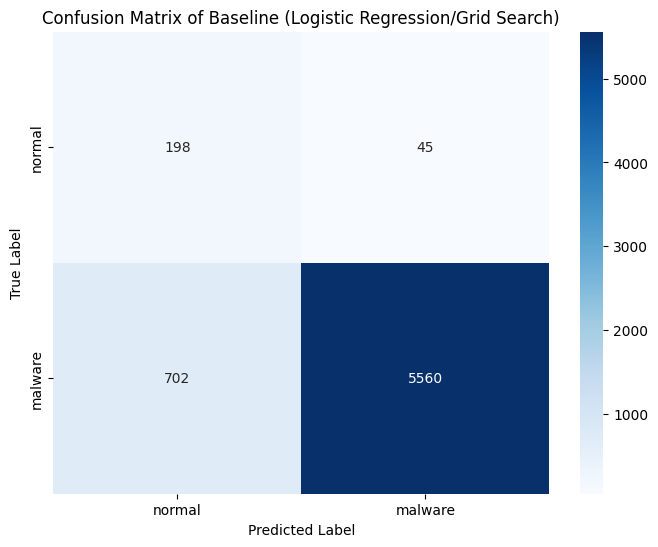

In [45]:
# test
y_test_preds = best_classifier.predict(X_test_array)
print(f"\n\nClass Report Baseline (Logistic Regression/Grid Search):\n{classification_report(y_test_array, y_test_preds, zero_division=0.0, target_names=["normal", "malware"])}")
plot_confusion_matrix("Baseline (Logistic Regression/Grid Search)", y_test_array.tolist(), y_test_preds, ["normal", "malware"])
baseline_metrics = classification_report(y_test_array, y_test_preds, zero_division=0.0, target_names=["normal", "malware"], output_dict=True)

The baseline performs surprisingly well. Despite ignoring API call ordering and working with 92% sparse vectors, it achieves macro F1 = 0.64 and correctly identifies 81% of normal samples — avoiding the majority-class collapse expected with such heavy imbalance. This is largely due to class_weight='balanced', and sets a strong reference point for more complex architectures.

In [46]:
# splitting to train and validation sets for future use
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['is_malware'])

In [47]:
# extract sequences(api)
train_seqs = df_train['api_call_sequence'].tolist()
val_seqs = df_val['api_call_sequence'].tolist()
test_seqs = df_test['api_call_sequence'].tolist()

In [48]:
# extract labels
train_labels = df_train['is_malware'].tolist()
val_labels = df_val['is_malware'].tolist()
test_labels = df_test['is_malware'].tolist()

In [49]:
# compute of pos-weights
pos_weight = torch.tensor([ (len(train_labels) - sum(train_labels)) / sum(train_labels) ]).to(device)

## 2. Feed Forward Neural Network (FFNN)

### 2.1 Preprocessing

min/max: 60/90 (train) | 70/100 (test)
mean/median: 75.04/75.00 (train) | 86.33/87.00 (test)


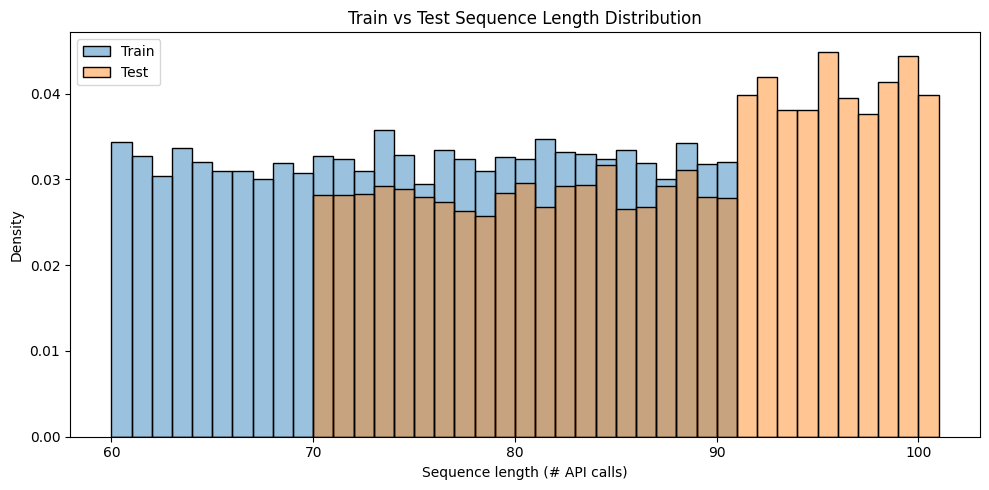

In [50]:
# extract length for train and test
train_lengths = [len(seq) for seq in train_seqs]
test_lengths = [len(seq) for seq in test_seqs]

print(f"min/max: {np.min(train_lengths)}/{np.max(train_lengths)} (train) | {np.min(test_lengths)}/{np.max(test_lengths)} (test)")
print(f"mean/median: {np.mean(train_lengths):.2f}/{np.median(train_lengths):.2f} (train) | {np.mean(test_lengths):.2f}/{np.median(test_lengths):.2f} (test)")

# distribution comparison of sequence lengths (train vs test)
plot_histogram("Train vs Test Sequence Length Distribution", train_lengths, test_lengths, "Sequence length (# API calls)", "Density")

From histogram it is clear, that their distribution is different, while training set API distribution between 60 up to 90, on test set amount is higher (70-100).

FFNN can only process fixed-size inputs

In [51]:
# estimate the fixed-size candidate using the training partition
max_length = np.max(train_lengths)
print(f"Maximum sequence length in the training set: {max_length}\nWe will use MAX_LEN = {max_length} for padding/truncation.")

Maximum sequence length in the training set: 90
We will use MAX_LEN = 90 for padding/truncation.


Used training set to estimate the fixed-size by find maximum sequence length

Used padding and truncating techniques to add and cut all API calls sequence on length equal to **max_len**.

Keep only first **max_len** api calls, and cut(truncate) exceed one.

In [52]:
# add <PAD> to assign unknown features for train set
seq_feature_names = feature_names + ['<PAD>']
api_to_idx['<PAD>'] = len(feature_names)

print(f"Total unique tokens (including <PAD> and <UNK>): {len(seq_feature_names)}")
print(f"Example Mapping: NtClose -> {api_to_idx['NtClose']}, <PAD> -> {api_to_idx['<PAD>']}, <UNK> -> {api_to_idx['<UNK>']}")

Total unique tokens (including <PAD> and <UNK>): 260
Example Mapping: NtClose -> 132, <PAD> -> 259, <UNK> -> 258


In [53]:
# map sequence of api calls to sequence of ids for train/val/test sets
X_train_ids = seq_api_to_id(train_seqs, api_to_idx, max_len=max_length)
X_val_ids = seq_api_to_id(val_seqs, api_to_idx, max_len=max_length)
X_test_ids = seq_api_to_id(test_seqs, api_to_idx, max_len=max_length)

In [54]:
# converting labels to numpy arrays
y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

In [55]:
# convert to tensors
X_train_ids_tensor = torch.tensor(X_train_ids, dtype=torch.long)
X_val_ids_tensor = torch.tensor(X_val_ids, dtype=torch.long)
X_test_ids_tensor = torch.tensor(X_test_ids, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

### 2.2 Train and Test the Models

In [56]:
# hyperparameters (common)
batch_size = 64
num_epochs = 100
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
input_dim = max_length
vocab_size = len(seq_feature_names)
output_dim = 1

In [57]:
# Create DataLoaders
train_dataset = TensorDataset(X_train_ids_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_ids_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_ids_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Epoch 20/100, Train Loss: 0.0601, Val Loss: 0.0722
Early stopping at epoch 37 (best val loss: 0.064897)
The function took 8.8357 seconds to execute.


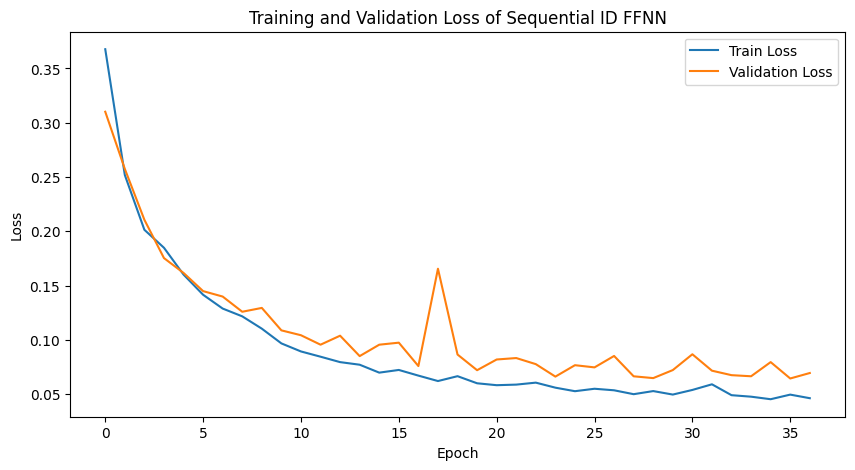

The function took 0.0607 seconds to execute.


Class Report Sequential ID FFNN:
              precision    recall  f1-score   support

      normal       0.05      0.42      0.08       243
     malware       0.97      0.66      0.78      6262

    accuracy                           0.65      6505
   macro avg       0.51      0.54      0.43      6505
weighted avg       0.93      0.65      0.76      6505



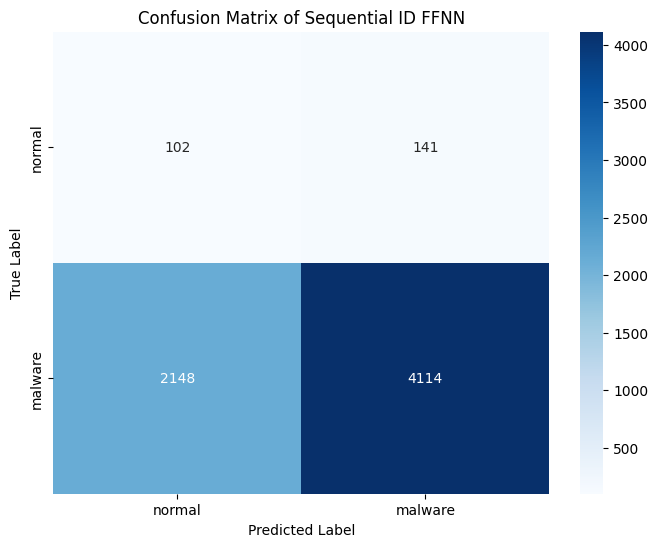

In [58]:
# hyperparameters (special)
lr = 1e-4
hidden_dim = 64
dropout = 0.0

# define Sequential Identifier model
model_si = FFNN(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, dropout=dropout).to(device)
opt_si = optim.AdamW(model_si.parameters(), lr=lr)

# training and evaluation of Sequential ID model
training_loop(model_si, train_loader, val_loader, device, opt_si, criterion, num_epochs, "Sequential ID FFNN", ffnn_stepper, 1e-3, 8)
metrics_si = testing_model(model_si, test_loader, device, "Sequential ID FFNN", ffnn_stepper)

Epoch 20/100, Train Loss: 0.0179, Val Loss: 0.0280
Early stopping at epoch 21 (best val loss: 0.026540)
The function took 5.8123 seconds to execute.


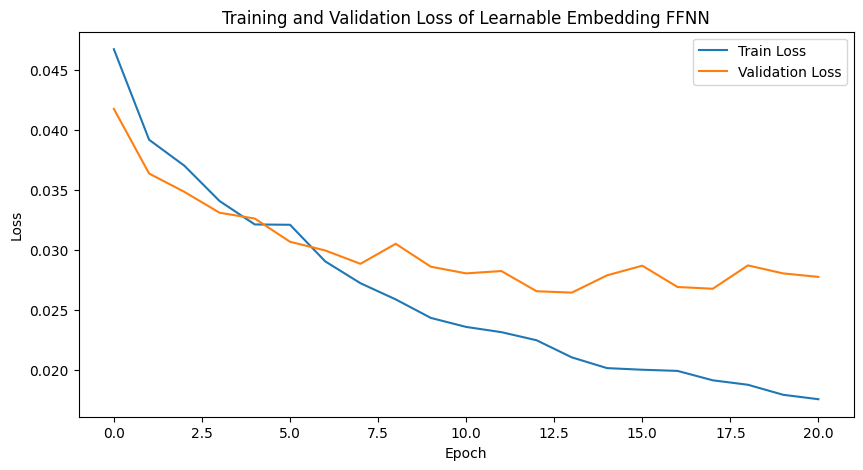

The function took 0.0530 seconds to execute.


Class Report Learnable Embedding FFNN:
              precision    recall  f1-score   support

      normal       0.21      0.73      0.32       243
     malware       0.99      0.89      0.94      6262

    accuracy                           0.89      6505
   macro avg       0.60      0.81      0.63      6505
weighted avg       0.96      0.89      0.92      6505



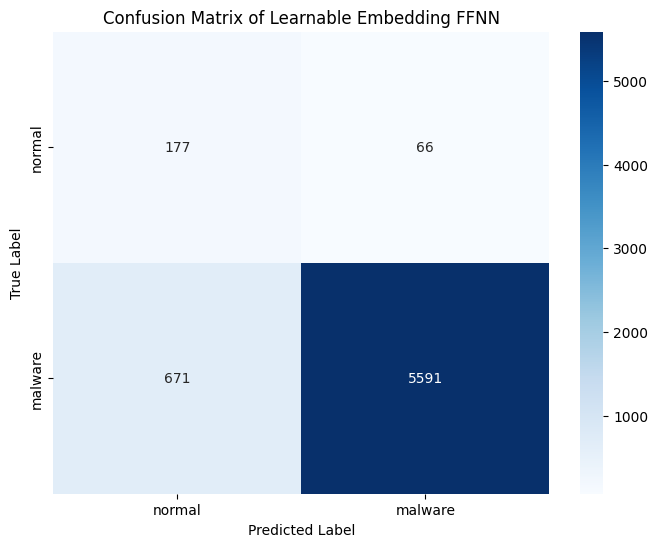

In [59]:
# hyperparameters (special)
lr = 1e-3
hidden_dim = 64
embed_dim = 64
dropout = 0.2

# define Learnable Embedding model
model_le = FFNN(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, output_dim=output_dim, dropout=0.2, is_embed=True).to(device)
opt_le = optim.AdamW(model_le.parameters(), lr=lr)

# training and evaluation of Learnable Embedding model
training_loop(model_le, train_loader, val_loader, device, opt_le, criterion, num_epochs, "Learnable Embedding FFNN", ffnn_stepper, 1e-3, 8)
metrics_le = testing_model(model_le, test_loader, device, "Learnable Embedding FFNN", ffnn_stepper)

For SeqID FFNN: dropout was set to 0.0 because the model is already weak at learning meaningful representations from integer IDs — adding dropout would further hurt its ability to converge. lr=0.0001 was chosen conservatively to avoid overshooting given the sparse gradient signal. For Learnable Embedding FFNN: lr=1e-3 was used based on experimentation — the embedding layer benefits from faster updates to learn meaningful API call representations. dropout=0.2 was added since the richer embedding space makes overfitting more likely. For both models: pos_weight was applied because the dataset is heavily imbalanced (6262 malware vs 243 normal), without it the model tends to ignore the minority class and predict malware only. hidden_dim=64 was chosen as a reasonable capacity given the vocabulary size of ~260 tokens.

Sequential ID model can't learn any useful patterns, instead it trusts on majority class and always predict as major (malware). It is clearly demonstrated on confusion matrix. At the same time, Learnable Embedding perform better than SeqID model, as it learnt useful patterns. However, it's f1-score is near the same with baseline model.

## 3. Recurrent Neural Network (RNN)

### 3.1 Preprocessing of Data

In [60]:
# convert each api call string to numeric value
train_ids = seq_api_to_id(train_seqs, api_to_idx)
val_ids = seq_api_to_id(val_seqs, api_to_idx)
test_ids = seq_api_to_id(test_seqs, api_to_idx)

In [61]:
# create datasets
train_dataset = APICallDataset(train_ids, train_labels)
val_dataset = APICallDataset(val_ids, val_labels)
test_dataset = APICallDataset(test_ids, test_labels)

We chose batch level max_len, and if any API sequence length less than it, we add special token `<PAD>`

On RNN max_len used dynamically per batch, not as FFNN used global max_len per whole data.

On FFNN models, global max is usually bigger, and need a lot of unnecessary padding, which use more memory, while on RNN since it's per batch max, some batch max can be locally low number.

### 3.2 Train and Test the Models

In [62]:
# hyperparameters
lr = 1e-4
batch_size = 64
num_epochs = 100
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
vocab_size = len(api_to_idx)
embed_dim = 64
hidden_dim = 256
output_dim = 1
num_layers = 2
dropout = 0.3
min_delta = 1e-4
patience = 8

In [63]:
# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size, collate_fn=partial(collate_fn, pad_index=api_to_idx['<PAD>']), shuffle=True)
val_loader = DataLoader(val_dataset, batch_size, collate_fn=partial(collate_fn, pad_index=api_to_idx['<PAD>']), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size, collate_fn=partial(collate_fn, pad_index=api_to_idx['<PAD>']), shuffle=False)

Epoch 20/100, Train Loss: 0.0244, Val Loss: 0.0322
Early stopping at epoch 25 (best val loss: 0.031512)
The function took 37.2898 seconds to execute.


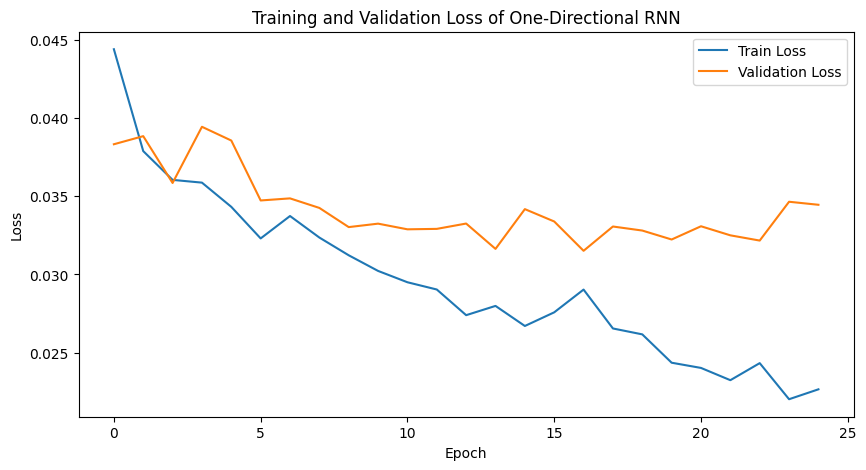

The function took 0.3153 seconds to execute.


Class Report One-Directional RNN:
              precision    recall  f1-score   support

      normal       0.18      0.65      0.28       243
     malware       0.98      0.89      0.93      6262

    accuracy                           0.88      6505
   macro avg       0.58      0.77      0.61      6505
weighted avg       0.95      0.88      0.91      6505



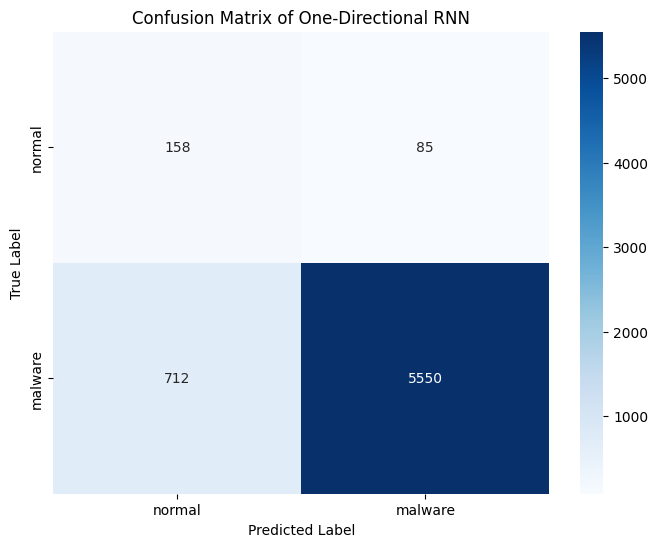

In [64]:
# define one-directional RNN
model_od = RNN(vocab_size, embed_dim, hidden_dim, output_dim, num_layers, padding_idx=api_to_idx['<PAD>'], dropout=dropout).to(device)
opt_od = optim.AdamW(model_od.parameters(), lr=lr)

# training and evaluation of one-directional RNN
training_loop(model_od, train_loader, val_loader, device, opt_od, criterion, num_epochs, "One-Directional RNN", rnn_stepper, min_delta, patience)
metrics_od = testing_model(model_od, test_loader, device, "One-Directional RNN", rnn_stepper)

Early stopping at epoch 15 (best val loss: 0.032832)
The function took 35.6922 seconds to execute.


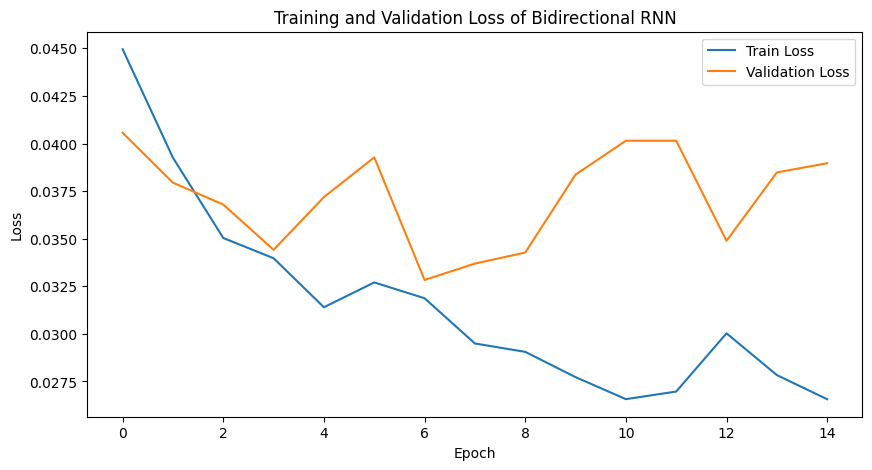

The function took 0.5193 seconds to execute.


Class Report Bidirectional RNN:
              precision    recall  f1-score   support

      normal       0.18      0.67      0.29       243
     malware       0.99      0.88      0.93      6262

    accuracy                           0.88      6505
   macro avg       0.58      0.78      0.61      6505
weighted avg       0.96      0.88      0.91      6505



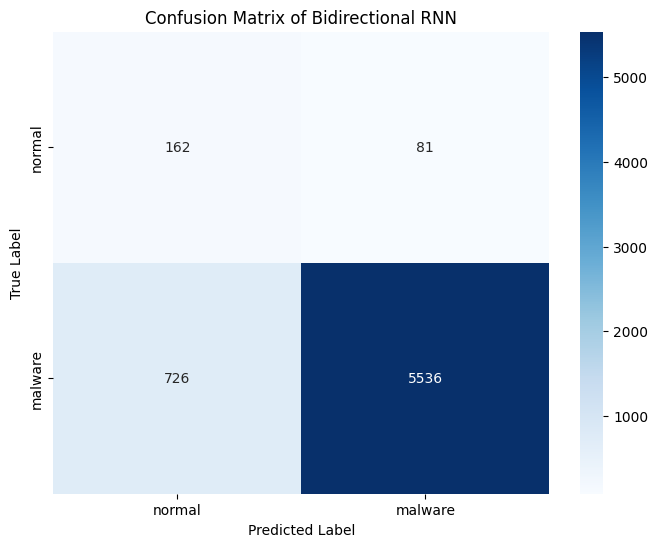

In [65]:
# define bidirectional RNN
model_bd = RNN(vocab_size, embed_dim, hidden_dim, output_dim, num_layers, api_to_idx['<PAD>'], dropout, bidirectional=True).to(device)
opt_bd = optim.AdamW(model_bd.parameters(), lr=lr)

# training and evaluation of bidirectional RNN
training_loop(model_bd, train_loader, val_loader, device, opt_bd, criterion, num_epochs, "Bidirectional RNN", rnn_stepper, min_delta, patience)
metrics_bd = testing_model(model_bd, test_loader, device, "Bidirectional RNN", rnn_stepper)

Epoch 20/100, Train Loss: 0.0185, Val Loss: 0.0229
Early stopping at epoch 33 (best val loss: 0.021932)
The function took 150.9224 seconds to execute.


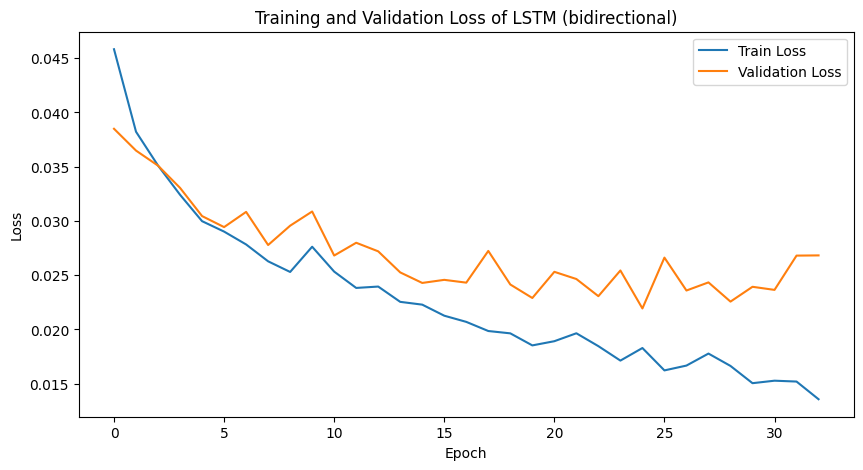

The function took 0.7856 seconds to execute.


Class Report LSTM (bidirectional):
              precision    recall  f1-score   support

      normal       0.26      0.81      0.39       243
     malware       0.99      0.91      0.95      6262

    accuracy                           0.91      6505
   macro avg       0.63      0.86      0.67      6505
weighted avg       0.96      0.91      0.93      6505



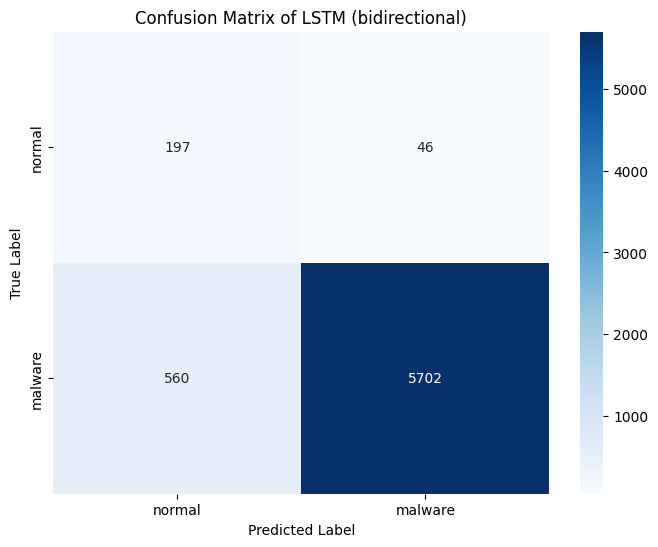

In [66]:
# define LSTM
model_bl = RNN(vocab_size, embed_dim, hidden_dim, output_dim, num_layers, api_to_idx['<PAD>'], dropout, is_lstm=True, bidirectional=True).to(device)
opt_bl = optim.AdamW(model_bl.parameters(), lr=lr)

# training and evaluation of LSTM
training_loop(model_bl, train_loader, val_loader, device, opt_bl, criterion, num_epochs, "LSTM (bidirectional)", rnn_stepper, min_delta, patience)
metrics_bl = testing_model(model_bl, test_loader, device, "LSTM (bidirectional)", rnn_stepper)

RNN uses extra parameter - **hidden state**, so each iteration depends on previous one. Which forces training process sequentially, while on FFNN process done maximum parallelized.

RNNs are generally less stable than FFNNs. Due to backpropagation through time over long sequences (~90 steps), RNNs suffer from vanishing/exploding gradient problems. This is evidenced by needing a much smaller lr=1e-4 compared to the FFNN, and the Bi-directional RNN triggering early stopping at just epoch 15. The LSTM mitigates this through its gating mechanism, achieving more stable training (stopped at epoch 33).

One-directional and Bi-directional RNNs (macro F1 = 0.61) both fall below the baseline (0.64), showing that adding sequence modeling alone is not sufficient — plain RNNs struggle with long sequences due to vanishing gradients. Only the Bi-LSTM (macro F1 = 0.67) surpasses the baseline, thanks to its gating mechanism that better captures long-range dependencies in API call sequences. This confirms that architectural complexity must be paired with the right mechanism to be effective.

## 4. Graph Neural Network (GNN)

### 4.1 Preprocessing of Data

We don’t need padding because the inputs of a GNN are graphs, which can have different sizes. However, the dataset still requires some preprocessing to be transformed into graph form, as seen in the course: each API sequence must be converted into nodes, the transitions between APIs into edges, and node features must be constructed for each graph.

We don’t need to truncate the testing sequences. As we saw in the lectures, a GNN works on graphs, and each sequence is transformed into a graph where each API call is a node and edges represent the transitions between them. Since graphs can have different numbers of nodes, the network can handle sequences of varying lengths. Truncating the sequences would actually remove some information, which could be important for the model to detect malware patterns. So, we can keep the testing sequences complete without any truncation.

Using a GNN in this scenario has the advantage that it can model the API calls as a graph, which allows the network to capture the structural relationships between calls, including loops and non‑linear dependencies. This is something an RNN struggles with, since an RNN only processes the sequence in order and mainly focuses on temporal relationships. However, the downside of using a GNN is that we lose some of the explicit sequential information. A GNN does not naturally preserve the exact temporal order of the calls it mostly sees which nodes are connected, not how many steps separate them. Another issue we discussed is that if an attacker obfuscates a malware by inserting many useless API calls between two important ones, the GNN might have a harder time noticing the link between those key calls. Because the graph gets larger and filled with “noise” nodes, the important transitions can become diluted inside the structure. An RNN, on the other hand, keeps the full order of the sequence, so it may be more sensitive to such obfuscation patterns.

In [67]:
# build graph data
train_adj, train_feat, train_labels = build_graph_data(df_train, api_to_idx)
val_adj, val_feat, val_labels = build_graph_data(df_val, api_to_idx)
test_adj, test_feat, test_labels = build_graph_data(df_test, api_to_idx)

Distribution of labels in this DataFrame : {np.int64(0): np.int64(489), np.int64(1): np.int64(12571)}
Distribution of labels in this DataFrame : {np.int64(0): np.int64(122), np.int64(1): np.int64(3143)}
Distribution of labels in this DataFrame : {np.int64(0): np.int64(243), np.int64(1): np.int64(6262)}


In [68]:
# create datasets
train_dataset = GraphDataset(train_adj, train_feat, train_labels)
val_dataset = GraphDataset(val_adj, val_feat, val_labels)
test_dataset = GraphDataset(test_adj, test_feat, test_labels)

GCN and GAT (macro F1 = 0.62) fall slightly below the baseline (0.64), while GraphSAGE (macro F1 = 0.64) ties it. No GNN surpasses the best overall model (Bi-LSTM, 0.67). GraphSAGE performs best among GNNs likely due to its neighborhood sampling aggregation, which is more robust than simple mean aggregation (GCN) or attention (GAT) on this small and imbalanced graph structure. Overall, GNNs perform comparably to the baseline but fail to leverage sequence structure since graph conversion loses temporal ordering.

### 4.2 Train and Test the Models

In [69]:
# hyperparameters
lr = 1e-4
weight_decay = 1e-4
batch_size = 64
num_epochs = 100
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_node_types = len(api_to_idx)
embed_dim = 64
hidden_dim = 64
output_dim = 1
heads= 4
dropout = 0.0
min_delta = 1e-3
patience = 8

In [70]:
# create dataloader
train_loader = GDataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = GDataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = GDataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Epoch 20/100, Train Loss: 0.0317, Val Loss: 0.0310
Early stopping at epoch 38 (best val loss: 0.028917)
The function took 40.5050 seconds to execute.


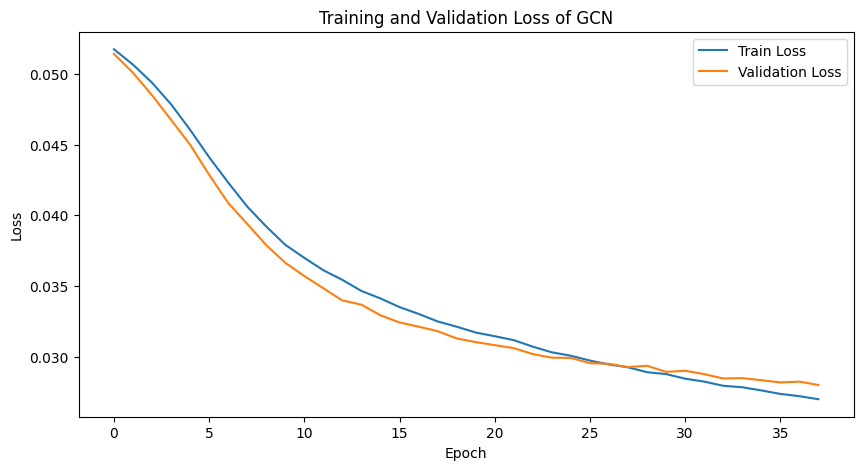

The function took 0.3629 seconds to execute.


Class Report GCN:
              precision    recall  f1-score   support

      normal       0.19      0.53      0.29       243
     malware       0.98      0.91      0.95      6262

    accuracy                           0.90      6505
   macro avg       0.59      0.72      0.62      6505
weighted avg       0.95      0.90      0.92      6505



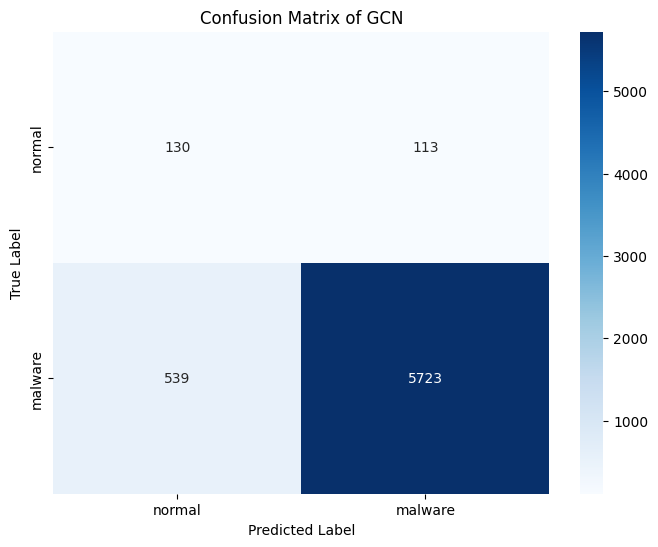

In [71]:
# define GCN
model_gcn = GNN(num_node_types, embed_dim, hidden_dim, output_dim, dropout).to(device)
opt_gcn = optim.AdamW(model_gcn.parameters(), lr=lr)

# training and evaluation of GCN
training_loop(model_gcn, train_loader, val_loader, device, opt_gcn, criterion, num_epochs, "GCN", gnn_stepper, min_delta, patience)
metrics_gcn = testing_model(model_gcn, test_loader, device, "GCN", gnn_stepper)

Epoch 20/100, Train Loss: 0.0293, Val Loss: 0.0294
Early stopping at epoch 37 (best val loss: 0.028102)
The function took 34.0977 seconds to execute.


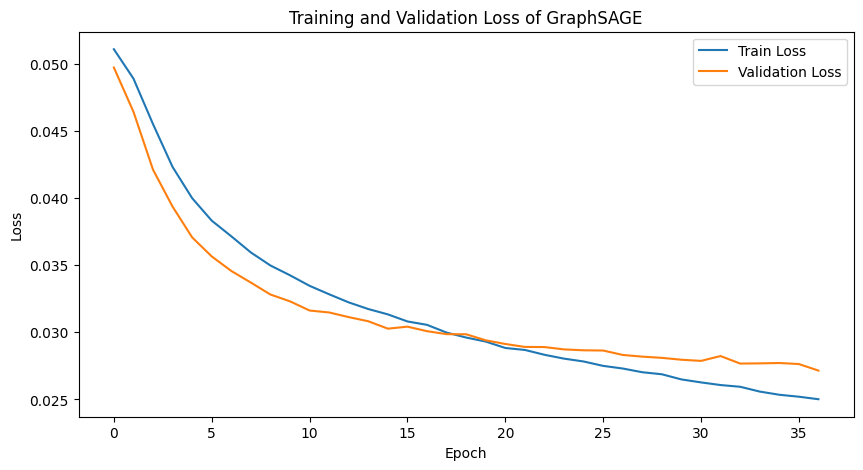

The function took 0.2446 seconds to execute.


Class Report GraphSAGE:
              precision    recall  f1-score   support

      normal       0.23      0.53      0.32       243
     malware       0.98      0.93      0.96      6262

    accuracy                           0.92      6505
   macro avg       0.61      0.73      0.64      6505
weighted avg       0.95      0.92      0.93      6505



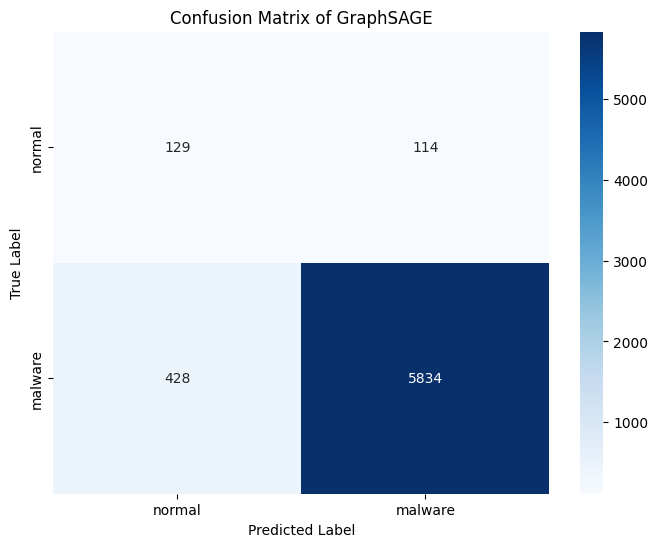

In [72]:
# define GraphSAGE
model_sage = GNN(num_node_types, embed_dim, hidden_dim, output_dim, dropout, is_sage=True).to(device)
opt_sage = optim.AdamW(model_sage.parameters(), lr=lr)

# training and evaluation of GraphSAGE
training_loop(model_sage, train_loader, val_loader, device, opt_sage, criterion, num_epochs, "GraphSAGE", gnn_stepper, min_delta, patience)
metrics_sage = testing_model(model_sage, test_loader, device, "GraphSAGE", gnn_stepper)

Epoch 20/100, Train Loss: 0.0258, Val Loss: 0.0276
Early stopping at epoch 28 (best val loss: 0.027647)
The function took 38.0001 seconds to execute.


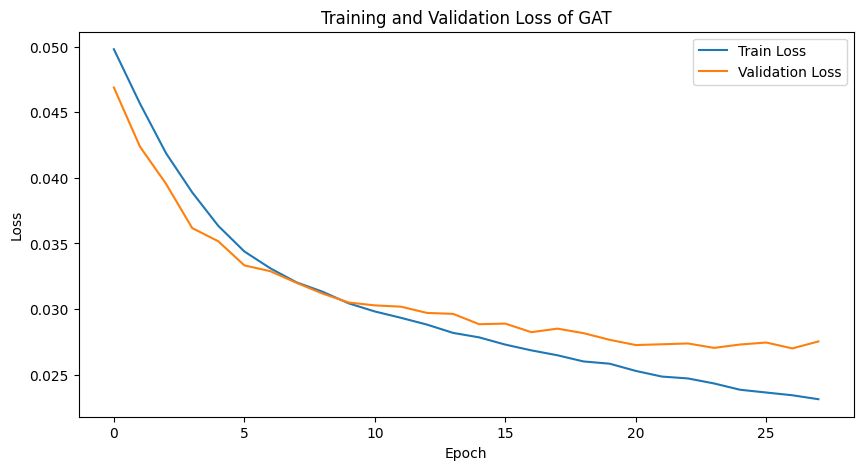

The function took 0.4263 seconds to execute.


Class Report GAT:
              precision    recall  f1-score   support

      normal       0.19      0.66      0.30       243
     malware       0.99      0.89      0.94      6262

    accuracy                           0.88      6505
   macro avg       0.59      0.78      0.62      6505
weighted avg       0.96      0.88      0.91      6505



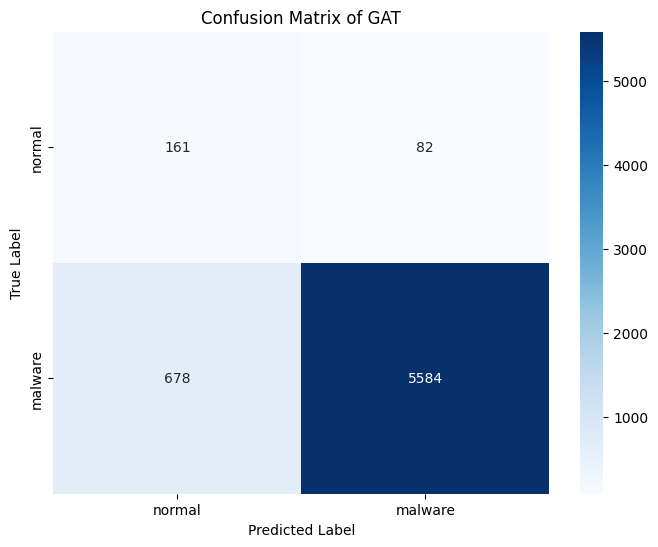

In [73]:
# define GAT
model_gat = GAT(num_node_types, embed_dim, hidden_dim, output_dim, heads, dropout).to(device)
opt_gat = optim.AdamW(model_gat.parameters(), lr=lr)

# training and evaluation of GAT
training_loop(model_gat, train_loader, val_loader, device, opt_gat, criterion, num_epochs, "GAT", gnn_stepper, min_delta, patience)
metrics_gat = testing_model(model_gat, test_loader, device, "GAT", gnn_stepper)

## 5 Analysis of the Results

The bar chart shows that SeqID FFNN performs worst (macro F1 = 0.43), collapsing toward majority-class prediction due to meaningless integer representations. The Baseline and Embedding FFNN perform comparably (~0.63–0.64), showing that frequency information alone captures much of the signal. Plain RNNs (0.61) fail to beat the baseline despite being more complex, while Bi-LSTM (0.67) is the best overall model thanks to its gating mechanism. GNNs cluster around 0.62–0.64, with GraphSAGE matching the baseline but none surpassing Bi-LSTM. Overall, architectural complexity does not guarantee better performance — the right inductive bias for the task matters more.

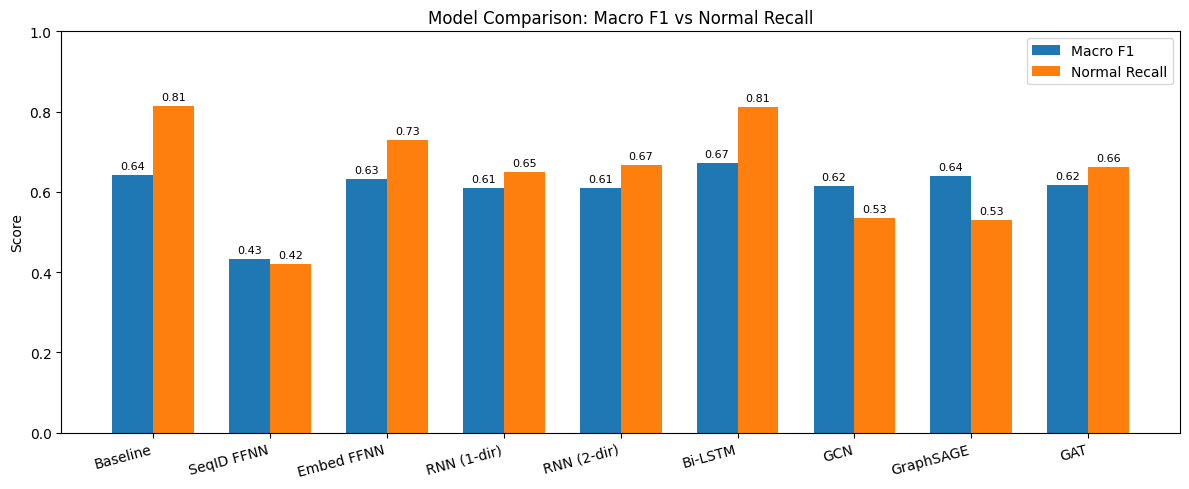

In [78]:
models_metrics = {
    "Baseline":    baseline_metrics,
    "SeqID FFNN":  metrics_si,
    "Embed FFNN":  metrics_le,
    "RNN (1-dir)": metrics_od,
    "RNN (2-dir)": metrics_bd,
    "Bi-LSTM":     metrics_bl,
    "GCN":         metrics_gcn,
    "GraphSAGE":   metrics_sage,
    "GAT":         metrics_gat,
}

plot_bar("Model Comparison: Macro F1 vs Normal Recall", models_metrics)